<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 3.77e-04 | train loss 0.9693 acc 0.568 | val loss 0.5992 acc 0.768 *


[ResNet-50] Epoch   2/100 | LR: 3.77e-04 | train loss 0.4997 acc 0.755 | val loss 0.6228 acc 0.782


[ResNet-50] Epoch   3/100 | LR: 3.77e-04 | train loss 0.3507 acc 0.841 | val loss 0.5224 acc 0.796 *


[ResNet-50] Epoch   4/100 | LR: 3.77e-04 | train loss 0.2013 acc 0.908 | val loss 0.7298 acc 0.737


...

[ResNet-50] Epoch   9/100 | LR: 3.77e-04 | train loss 0.0809 acc 0.970 | val loss 0.9886 acc 0.794


[ResNet-50] Epoch  10/100 | LR: 3.77e-04 | train loss 0.0815 acc 0.971 | val loss 0.7254 acc 0.826


[ResNet-50] Epoch  11/100 | LR: 3.77e-04 | train loss 0.0836 acc 0.965 | val loss 0.6849 acc 0.830


[ResNet-50] Epoch  12/100 | LR: 3.77e-04 | train loss 0.0763 acc 0.975 | val loss 0.9023 acc 0.780


[ResNet-50] Epoch  13/100 | LR: 3.77e-04 | train loss 0.0796 acc 0.971 | val loss 0.7113 acc 0.820

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 13.

[ResNet-50] Restored best checkpoint (val loss = 0.5224)


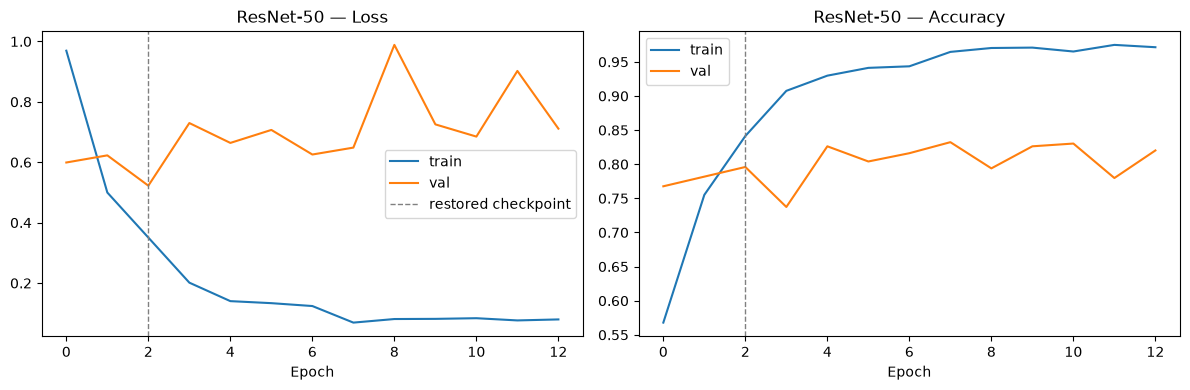

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.786


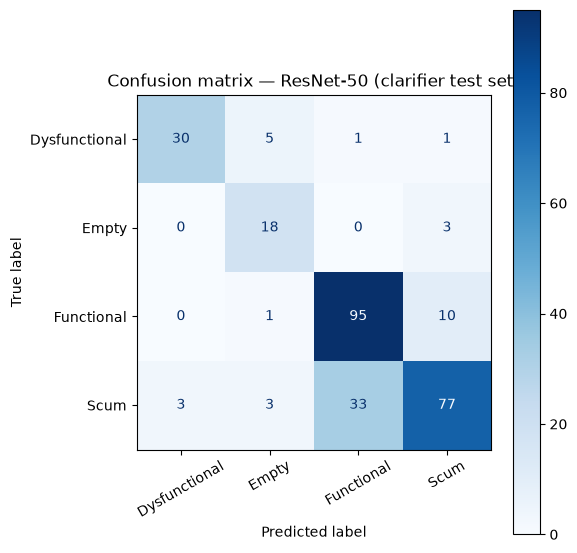

               precision    recall  f1-score   support

Dysfunctional      0.909     0.811     0.857        37
        Empty      0.667     0.857     0.750        21
   Functional      0.736     0.896     0.809       106
         Scum      0.846     0.664     0.744       116

     accuracy                          0.786       280
    macro avg      0.790     0.807     0.790       280
 weighted avg      0.799     0.786     0.784       280



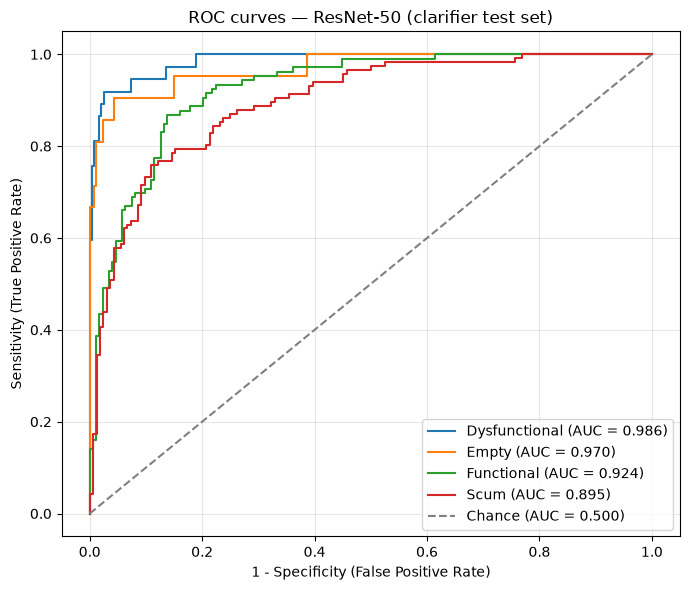

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.986
  Empty          : 0.970
  Functional     : 0.924
  Scum           : 0.895

Mean AUC (over 4/4 classes with test examples): 0.944


(np.float64(0.7857142857142857),
 {'Dysfunctional': 0.985985985985986,
  'Empty': 0.969847398418827,
  'Functional': 0.9244740837128606,
  'Scum': 0.8953427249789739})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/clarifier_noaug/results_clarifier_resnet50_stratified.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
